# QCFD Domain Tools

This notebook compares tools that claim direct or adjacent QCFD/QLBM relevance.

Corpus anchors: `QRE2`, `QRE4`, `LBM14`, `CAR7`, `PRIM8`, `IO4`, `IO5`, `IO7`, `IO8`.

Compact object: an assumption-fit matrix for QLBM/domain packages against the periodic D2Q9 Taylor-Green benchmark.


tooling atlas output directory: .cache\tooling_atlas


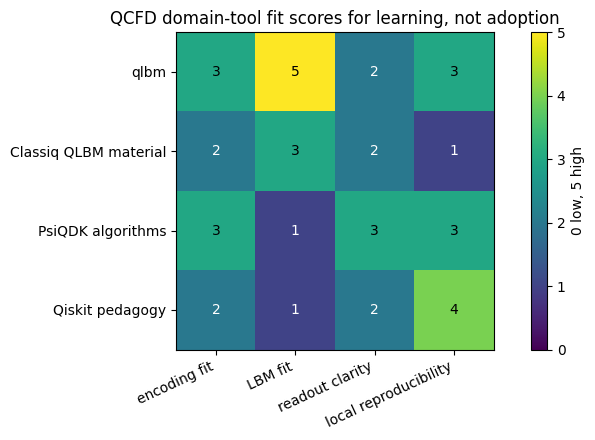

optional package availability: {'qlbm': True, 'classiq': False}
falsifiable check: no domain tool is treated as solving readout/loading gates by default


In [1]:
from pathlib import Path
import importlib.util
import json
import math

import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = Path('.cache/tooling_atlas')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def has_module(name: str) -> bool:
    try:
        return importlib.util.find_spec(name) is not None
    except ModuleNotFoundError:
        return False


print(f'tooling atlas output directory: {OUTPUT_DIR}')

domain_tools = [
    {'tool': 'qlbm', 'encoding fit': 3, 'LBM fit': 5, 'readout clarity': 2, 'local reproducibility': 3, 'note': 'QLBM-specific circuits/lattices; may not match QRE2.'},
    {'tool': 'Classiq QLBM material', 'encoding fit': 2, 'LBM fit': 3, 'readout clarity': 2, 'local reproducibility': 1, 'note': 'High-level synthesis/platform material; likely account/platform gated.'},
    {'tool': 'PsiQDK algorithms', 'encoding fit': 3, 'LBM fit': 1, 'readout clarity': 3, 'local reproducibility': 3, 'note': 'FTQC primitives useful after route boxes exist.'},
    {'tool': 'Qiskit pedagogy', 'encoding fit': 2, 'LBM fit': 1, 'readout clarity': 2, 'local reproducibility': 4, 'note': 'Good circuit teaching layer, not QCFD domain logic.'},
]
metrics = ['encoding fit', 'LBM fit', 'readout clarity', 'local reproducibility']
values = np.array([[row[m] for m in metrics] for row in domain_tools])

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(values, vmin=0, vmax=5, cmap='viridis')
ax.set_xticks(range(len(metrics)), metrics, rotation=25, ha='right')
ax.set_yticks(range(len(domain_tools)), [row['tool'] for row in domain_tools])
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        ax.text(j, i, str(values[i, j]), ha='center', va='center', color='white' if values[i, j] < 3 else 'black')
ax.set_title('QCFD domain-tool fit scores for learning, not adoption')
fig.colorbar(im, ax=ax, label='0 low, 5 high')
plt.tight_layout()
plt.show()

availability = {name: has_module(name) for name in ['qlbm', 'classiq']}
print('optional package availability:', availability)
assert any(row['tool'] == 'qlbm' and row['LBM fit'] == 5 for row in domain_tools)
assert all(row['readout clarity'] < 5 for row in domain_tools)
print('falsifiable check: no domain tool is treated as solving readout/loading gates by default')


In [2]:
# Sandbox package inventory: generated from .cache/tooling_atlas/installed_packages_report.json.
from pathlib import Path
import json

report_path = Path('.cache/tooling_atlas/installed_packages_report.json')
if report_path.exists():
    report = json.loads(report_path.read_text(encoding='utf-8'))
    rows = []
    for env_name, env in report.items():
        for package, info in env['packages'].items():
            rows.append({
                'env': env_name,
                'package': package,
                'version': info.get('version') or '',
                'import': 'ok' if info.get('import_ok') else 'blocked',
                'note': info.get('error') or '',
            })
    try:
        import pandas as pd
        display(pd.DataFrame(rows))
    except Exception:
        for row in rows:
            print(f"{row['env']:12s} {row['package']:16s} {row['version']:10s} {row['import']:8s} {row['note']}")
else:
    print('No sandbox report found yet. Run the package audit to create .cache/tooling_atlas/installed_packages_report.json.')

No sandbox report found yet. Run the package audit to create .cache/tooling_atlas/installed_packages_report.json.


## What This Cannot Prove

A QLBM package can build or inspect QLBM circuits, but it does not automatically match the Jennings `QRE2/QRE4` route. The comparison must still state encoding, loading/reloading, selected observables, and sample complexity.
